In [238]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x +5

In [4]:
f(3)

20

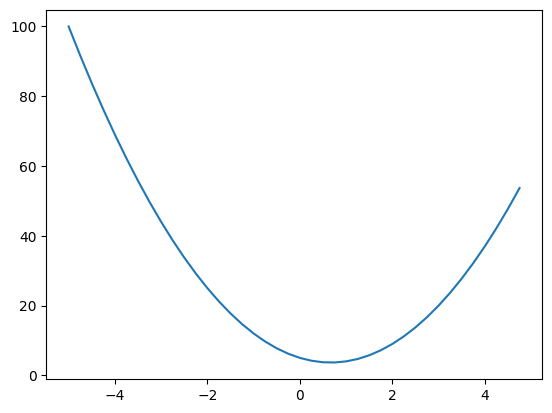

In [12]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)

plt.plot(xs, ys)

In [16]:
h = 0.0001
x = 3.0
f(x)
(f(x+h) - f(x))/h

14.000300000063248

In [28]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c
a -= h
b += h
d3 = a*b + c
b -= h
c += h
d4 = a*b + c

print('d1 =',d1)
print('d2 =',d2)
print('d3 =',d3)
print('d4 =',d4)

print('d2-d1/h = ', (d2-d1)/h)
print('d3-d1/h = ', (d3-d1)/h)
print('d4-d1/h = ', (d4-d1)/h)

d1 = 4.0
d2 = 3.999699999999999
d3 = 4.0002
d4 = 4.0001
d2-d1/h =  -3.000000000010772
d3-d1/h =  2.0000000000042206
d4-d1/h =  0.9999999999976694


In [ ]:
# For the expression a * b + c, by nudging it a little on a, b, and c respectively,
# we were able to find their respective slopes at each point.
# AKA, we were able to find how some unit of a, b, and c individually change the output.
# AKA, we were able to find their partial derivatives.

# If we treat b and c as constants, when we nudge a, the output changes by about -3.
# Makes sense, because taking the derivative of f(a) = -3a + 10 with respect to a = -3.
# If we treat a and c as constasnts, when we nudge b, the output changes by about 2. 
# Makes sense, because taking the derivative of f(b) = 2b + 10 with respect to b = 2.
# If we treat a and b as constasnts, when we nudge c, the output changes by about 1. 
# Makes sense, because taking the derivative of f(c) = c with respect to c = 1.

# The accuracy increases as h approaches 0.

In [158]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

    def tanh(self):
        x = self.data
        out = Value(((math.exp(2*x)-1)/(math.exp(2*x)+1)), (self,),'tanh')
        return out

In [ ]:

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label='e'
d = e+c; d.label='d'
f = Value(-2.0, label='f')
L = d*f; L.label='L'

# equivalent to d = (a.__mul__(b)).__add__(c)

# d = (2.0 * -3.0) + 10.0
# d = 4.0

#print("d: ", d.data, d._prev, d._op)


#for node in d._prev:
#    print(node.data, node._prev, node._op)

#d holds the other objects as its children. Each object holds its own children (if any)

In [79]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

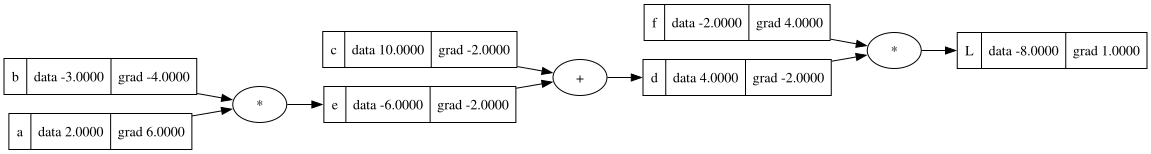

In [90]:
draw_dot(L)

In [89]:
# Now we need to use chain rule to find the partial derivatives of L with respect to each variable
# AKA, how each variable affects the output L.
# To find the influence of more elementary variables to the output, we need to multiply their rates of change to chain their effect.
# To make it more intuitive, imagine that rate of change in distance biking is 2x as fast as walking and car is 4x as fast as biking
# To find the rate of change in distance due to car with respect to walking, we simply multiply the rates of change: 4 * 2 = 8.
# AKA, db/dw = 2, dc/db = 4, -> dc/dw = dc/db * db/dw -> 4 * 2 = 8

# In our case we can compute gradients in our example of chained expressions a*b = e, e+c = d, d*f = L
# AKA finding how L is affected by some unit of change in each variable a, b, c, d, e, and f.
# dL/dL = 1
# dL/df = 4
# dL/dd = -2
# dL/de = dL/dd * dd/de = -2*1 = -2
# dL/dc = dL/dd * dd/dc = -2*1 = -2
# dL/da = dL/dd * dd/de * de/da = -2*1*-3 = 6
# Or, alternatively, dL/da = dL/de * de/da = -2*-3 = 6 (since dL/de = dL/dd * dd/de)
# dL/db = dL/dd * dd/de * de/db = -2*1*2 = -4
# Or, alternatively, dL/db = dL/de * de/da = -2*2 = -4 (since dL/de = dL/dd * dd/de)

# Manually set the gradients accordingly:
a.grad = 6.0
b.grad = -4.0
c.grad = -2.0
d.grad = -2.0
e.grad = -2.0
f.grad = 4.0
L.grad = 1.0

In [69]:
# We can double check our analysis by computing each partial derivative. As h approaches 0, these estimates become more accurate:

def pd_test():
    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e+c; d.label='d'
    f = Value(-2.0, label='f')
    L = d*f; L.label='L'
    L1 = L.data

    # Nudge the variable who's partial derivative we're checking by h
    a = Value(2.0 + h, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e+c; d.label='d'
    f = Value(-2.0, label='f')
    L = d*f; L.label='L'
    L2 = L.data
    
    
    # Compute the partial derivative
    print((L2 - L1)/h)

pd_test()

6.000000000021544


In [147]:


# The sign of the gradient tells us the direction of steepest ascent, aka which direction to nudge the variable to maximize the output.
# AKA if the gradient is negative, nudge the value negatively, and if the gradient is positive, nudge the value positively.
# Each nudge in the values is a step towards the local maximum.

# We use this equation to update each variable's value towards the local maximum: variable.data += learning_rate * variable.grad

# However, in a neural network, where our goal is to minimize the loss function L, we want to do the opposite.
# To find the local minimum, we nudge the values in the opposite direction of the gradient sign.
# AKA if the gradient is negative, nudge the value positively, and if the gradient is positive, nudge the value negatively.

# We use this equation to update each variable's value towards the local minimum: variable.data -= learning_rate * variable.grad

# The sign of the variable's gradient tells us the direciton we need to nudge the variable's value to get the steepest ascent in the output
# The magnitude of the gradient scales how big each step is for that specific variable.
# The learning rate is a universal knob for how big each step is for all variables.

# Lets use the equation to compute our first back propogation and minimize L

def backprop_test():

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e+c; d.label='d'
    f = Value(-2.0, label='f')
    L = d*f; L.label='L'

    a.grad = 6.0
    b.grad = -4.0
    c.grad = -2.0
    f.grad = 4.0
    
    print(L.data)

    # Set the learning rate
    lr = 0.85
    
    a.data -= lr * a.grad
    b.data -= lr * b.grad
    c.data -= lr * c.grad
    f.data -= lr * f.grad

    # Notice we do not update d.data and e.data since they're intermediate nodes. 
    # d and e are not independent variables we nudge. They get their values from a, b, c, and f.
    # We calculated the gradients for d and e only for the purpose of finding the gradients of the most elementary variables a, b, c, and f.

    e = a * b
    d = e + c
    L = d * f
    
    print(L.data)

backprop_test()

-8.0
-56.484


In [94]:
print(a.data)

2.0


In [213]:
# Lets try to do a backpropogation example on a neuron
# We'll have two inputs: x1 = 2, w1 = -3, x2 = 0, w2 = 1, and a bias b = 6.88

x1 = Value(2.0, label="x1")
w1 = Value(-3.0, label="w1")
x2 = Value(0.0, label="x2")
w2 = Value(1.0, label="w2")
b = Value(6.881373587019543, label="b")

x1w1 = x1*w1; x1w1.label="x1w1"
x2w2 = x2*w2; x2w2.label="x2w2"
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label="x1w1x2w2"
n = x1w1x2w2+b; n.label="n"

o = n.tanh(); o.label="o"

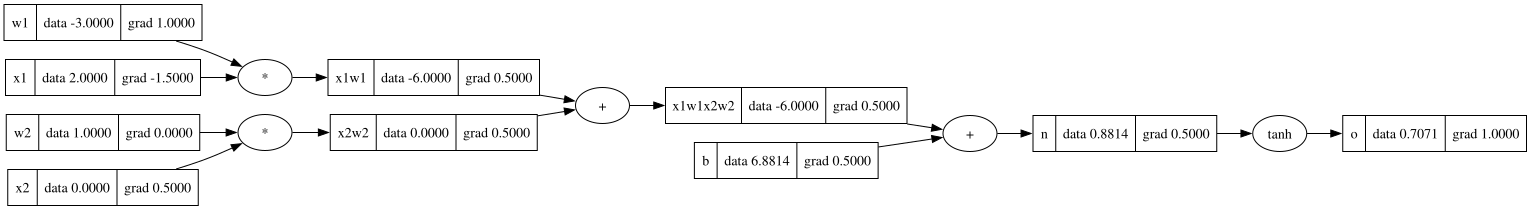

In [217]:
draw_dot(o)

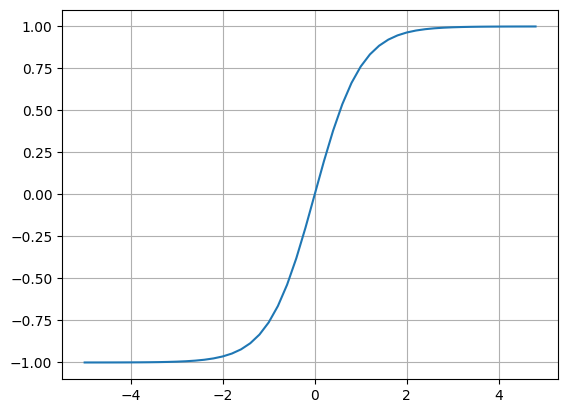

In [151]:
# Lets see an example of how tanh works as a squashing function
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid();

# We need to implement it in the Value object because we cannot call tanh directly on the data

In [ ]:
# Instead of painstakingly analyzing each individual gradient like last time,
# Lets build a way to be able to backpropogate each gradient automatically.
# To do this, we need a gradient calculator function for each type of operation.

# For addition, the derivative of each addend with respect to the output would just be:
# 1 * the gradient of the output with respect to the sum variable
# e.g. for a + b = c -> output L
# da/dL = 1 * dL/dc
# db/dL = 1 * dL/dc

# For multiplication, the derivative of each factor with respect to the output would be:
# [The other factor] * the gradient of the output with respect to the sum variable
# e.g. for a = 3, b = 4 for a * b = c -> output L
# da/dL = b * dL/dc = 4 * dL/dc
# db/dL = a * dL/dc = 3 * dL/dc

# For tanh, d/dx tanhx = 1-tan^2x


In [162]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._backward = lambda: None
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1 * out.grad
            other.grad += 1 * out.grad
            
        out._backward = _backward
        
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad  += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        
        return out

    def tanh(self):
        x = self.data
        out = Value(((math.exp(2*x)-1)/(math.exp(2*x)+1)), (self,),'tanh')

        def _backward():
            self.grad += (1 - out.data**2) * out.grad

        out._backward = _backward
        
        return out

In [212]:
# Setting the default gradient for the output
o.grad = 1.0
print(o.grad)

# Testing _backward() on each
o._backward()
n._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

1.0


In [209]:
# There's one more thing we can do to make our backpropogation more automatic
# We need a way to recursively run _backward() only if its parent already has a gradient.
# We can use reverse topological sorting for this
# Topological sort recursively adds all of the children of a node before appending itself
# We need the reverse of the resulting list because we need to start by-
# computing the gradient of the output, and then call _backward() recursively on the node's children.

topo = []
visited = set()

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)

print("The original topological sort: \n", *topo, sep="\n")
print("\n")
reversed_topo = topo[::-1]
print("The reversed topological sort: \n", *reversed_topo, sep="\n")

The original topological sort: 

Value(data=6.881373587019543)
Value(data=2.0)
Value(data=-3.0)
Value(data=-6.0)
Value(data=1.0)
Value(data=0.0)
Value(data=0.0)
Value(data=-6.0)
Value(data=0.8813735870195432)
Value(data=0.7071067811865476)


The reversed topological sort: 

Value(data=0.7071067811865476)
Value(data=0.8813735870195432)
Value(data=-6.0)
Value(data=0.0)
Value(data=0.0)
Value(data=1.0)
Value(data=-6.0)
Value(data=-3.0)
Value(data=2.0)
Value(data=6.881373587019543)


In [210]:
# Now we can run _backward() on eac h object in the list in the proper sequence for backpropogation

# Initialize the output gradient
o.grad = 1.0

# Call _backward() in reversed topo sequence
for node in reversed_topo:
    node._backward()

    for prev in node._prev:
        print(prev.grad)


0.9999999999999998
1.4999999999999996
1.4999999999999996
1.9999999999999996
1.9999999999999996
0.0
2.4999999999999996
-7.499999999999998
4.999999999999999


In [505]:
# We can add this functionality to our Value class to backpropogate at a certain node:
# Edit: added __neg__(), __sub__(), and __pow__() for the MLP portion
# Edit: added __rsub__(), __radd__(), __rmul__(), 

class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._backward = lambda: None
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data})"

    def __neg__(self):
        #out = Value(-self.data, (self,), '-')

        #def _backward():
           #self.grad += -1 * out.grad

        #out._backward = _backward
        
        #return out
        return self * -1

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1 * out.grad
            other.grad += 1 * out.grad
            
        out._backward = _backward
        
        return out

    def __sub__(self, other):
        #other = other if isinstance(other, Value) else Value(other)
        #out = Value(self.data - other.data, (self, other), '-')
        
        #def _backward():
            #self.grad += 1 * out.grad
            #other.grad += -1 * out.grad

        #out._backward = _backward
            
        #return out
        return self + (-other)
        
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad  += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        
        return out

    def __radd__(self, other):
        return self + other

    def __rsub__(self, other):
        return self + (-other)

    def __rmul__(self, other):
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only int/float supported"
        out = Value(self.data**other, (self,), f'**{other}', )

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad

        out._backward = _backward
        
        return out

    def tanh(self):
        x = self.data
        out = Value(((math.exp(2*x)-1)/(math.exp(2*x)+1)), (self,),'tanh')

        def _backward():
            self.grad += (1 - out.data**2) * out.grad

        out._backward = _backward
        
        return out
        
    def backward(self):
        topo = []
        visited = set()
        
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        reversed_topo = topo[::-1]

        self.grad = 1.0
        for node in reversed_topo:
            node._backward()
        
        

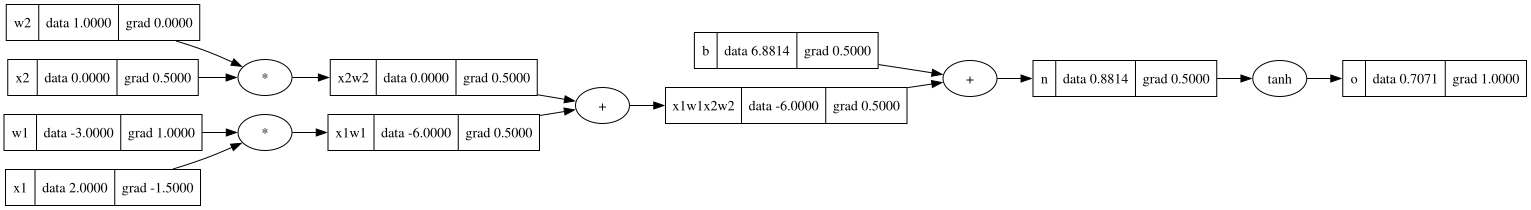

In [220]:
x1 = Value(2.0, label="x1")
w1 = Value(-3.0, label="w1")
x2 = Value(0.0, label="x2")
w2 = Value(1.0, label="w2")
b = Value(6.881373587019543, label="b")

x1w1 = x1*w1; x1w1.label="x1w1"
x2w2 = x2*w2; x2w2.label="x2w2"
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label="x1w1x2w2"
n = x1w1x2w2+b; n.label="n"

o = n.tanh(); o.label="o"

o.backward()
draw_dot(o)

In [ ]:
# We just built a single neuron that takes 2 inputs of data and 3 learnable parameters (w1, w2 for the data x1 and x2, and the bias b)

In [309]:
# In deep learning, we have a "deep" MLP (multi-layer perceptron) which is basically a collection of deep layers of neurons.
# The combination of layers are meant to capture hierarchically abstract representations in the data, with later layers learning more abstract patterns from previous ones
# An MLP consists of an input layer with some inputs x, some hidden layers, and an output layer which will give us our prediction.
# From this prediction, we will calculate the loss, AKA how different the model's y-predictions are to the y-ground_truth for our input data x.
# We will use MSE (mean square error) as the loss function for this example.
# Lets build an MLP.

# Note: nin is how many inputs in the input layer that will feed into the neurons, nout is how many neurons in a layer, and nouts is a list of layers with varying amounts of neurons.

class Neuron:
    
    # For each neuron, we need the sum from i to n of (w_i * x_i + b) + ... + (w_n * x_i + b). Where n is the number of inputs and weights.
    # Note that if and only if we have n inputs, we will have n weights.
    
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
        
    def __call__(self, x):
        act = sum(((wi * xi) for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]
        
class Layer:
    
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
        
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return[p for neuron in self.neurons for p in neuron.parameters()]
       
class MLP:

    # Only the first layer has nin number of inputs for each neuron, the rest of the layers needs each of its neurons to accept nout of the previous layer.
    # E.g. for MLP(2 [3, 4, 1]) with number of inputs = 2 and number of neurons for each layer is [3, 4, 1], We will build self.layers = [Layer(2, 3), Layer(3, 4), Layer(4, 1)]
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x 

    def parameters(self):
        return[p for layer in self.layers for p in layer.parameters()]

In [361]:
x = [[1.0, 3.0, -4.0],
     [5.0, -2.0, 5.0],
     [6.0, 7.0, 1.0],
     [3.0, 2.0, -4.0]]

ygt = [1.0, -1.0, 0.0, 1.0]

n = MLP(3, [3, 3, 1])

y_pred = [n(xi) for xi in x]

loss = sum(((ygti - y_predi) ** 2) for ygti, y_predi in zip(ygt,y_pred))

# I got this error when attempting y_gti - ypredi: unsupported operand type(s) for -: 'float' and 'Value'
# Because I tried to attempt __sub__(self,other) on __sub__(float, Value), which are incompatible argument types for my function in that order.
# And after I patched that by reversing their order, I got another one: unsupported operand type(s) for +: 'int' and 'Value'
# Because I tried to call sum() which python interprets as adding my Value the default int 0, attempting __add__(self, other) on __add__(int, Value), again, incompatible.

# And first I did the workaround by hardcoding: loss = sum(((y_predi - ygti) ** 2) for ygti, y_predi in zip(ygt,y_pred), Value(0.0))
# But realized that I need to make the Value class more robust to handle refelcted orders of (self, other) and (other, self) so operations are order agnostic
# So I needed to implement the reflected versions __radd__() and __rsub__()

print(loss)

Value(data=4.068627131746761)


In [362]:
# And now lets run gradient descent on the loss

loss.backward()
print(loss)

Value(data=4.068627131746761)


In [363]:
# We will have calculated gradients for every Value object that contributed to the final output
# But only the gradients of the weights and biases are useful because they are the learnable parameters.
# Let's put those useful gradients in a list so we can nudge them in the opposite direction of the gradient

#Edit: I made this part more modular by adding a parameters() method to MLP, Layer, and Neuron.
#wandb = []
#for layer in n.layers:
#    for neuron in layer.neurons:
#        wandb.append(neuron.w, neuron.b)

for p in n.parameters():
    print(p.grad)

-0.35985431722453165
-0.34675212697408
0.594988734937944
-0.15155879178479792
0.869613272200483
1.6386527719753543
-2.373639949041495
0.5917611549472113
-2.2943563558569444
-3.581314456802664
5.406384488685889
-1.3505964641463883
-0.046889707062682716
-0.048516388478552955
-0.014403147759033251
0.06040532358206009
-3.4234596811524596
-3.493491726344015
-1.176472950458546
4.450575830896799
-1.0719743804882311
-0.6320640127781766
-0.016606574506885075
1.3145432136511497
-1.068825628855366
0.532593998312894
-3.9984746914903626
4.989972911865756


In [364]:
# Awesomesauce. Now that we have a list of our learnable parameters, we can adjust each of them accordingly.

# Remember, we want to go in the opposite direction of the gradient to minimize the output loss.
# If the gradient is positive, we want to nudge the paramater in the negative direction, vice versa.
# Since our loss function is high dimensional, we need to be careful of how much we nudge the parameters.
# If we take too large a step, we could "step over" the minimum we're trying to get to and miss it.
# If we take too little of steps, it is simply inefficient.

# Lets start with a step size of 0.01
a = 0.01

for p in n.parameters():
    p.data -= a * p.grad

y_pred = [n(xi) for xi in x]

loss = sum(((ygti - y_predi) ** 2) for ygti, y_predi in zip(ygt,y_pred))

print(loss)

Value(data=2.6849447498159478)


In [368]:
# Crucially, don't forget to zero the gradients to prevent gradient accumulation for the next pass

for p in n.parameters():
    p.grad = 0

In [506]:
# Now we have everything we need to create the entire training loop.

# Here are the steps for each loop
# 1. Load data and initialize MLP (once)
# 2. forward pass
# 3. backward pass
# 4. parameter update
# 5. zero gradients
# 6. forward pass
# 7. Check loss
# 8. repeat from 2. to 7. until loss is as low as desired

# Load data and initialize MLP
x = [
    [2.0, 2.0],
    [2.5, 1.5],
    [1.5, 2.5],
    [2.0, 1.8],
    [-2.0, -2.0],
    [-2.5, -1.5],
    [-1.5, -2.5],
    [-2.0, -1.8],
]
ygt = [1.0, 1.0, 1.0, 1.0, -1.0, -1.0, -1.0, -1.0]
n = MLP(2, [4, 4, 1])

y_pred = [n(xi) for xi in x]

loss = sum(((ygti - y_predi) ** 2) for ygti, y_predi in zip(ygt,y_pred))

In [507]:
# The loopable part
def step(steps):
    for step in range(1, steps+1):
        # Forward pass
        y_pred = [n(xi) for xi in x]
        loss = sum(((ygti - y_predi) ** 2) for ygti, y_predi in zip(ygt,y_pred))
        
        # Backward pass
        loss.backward()
        
        # Parameter update
        a = 0.01
        
        for p in n.parameters():
            p.data -= a * p.grad
        
        # Zero gradients
        
        for p in n.parameters():
            p.grad = 0
        
        print(step, loss)

step(100)

1 Value(data=14.240430584199265)
2 Value(data=13.297565793136304)
3 Value(data=11.552221191256052)
4 Value(data=8.300397336377799)
5 Value(data=4.08345132657521)
6 Value(data=1.7354344437116591)
7 Value(data=0.9774701574034704)
8 Value(data=0.6717330418727263)
9 Value(data=0.5121279360781051)
10 Value(data=0.41484420855484533)
11 Value(data=0.34946160464237247)
12 Value(data=0.30250064447618213)
13 Value(data=0.26711559680848823)
14 Value(data=0.2394725419595064)
15 Value(data=0.21726094671635307)
16 Value(data=0.19900672388736898)
17 Value(data=0.1837256200612137)
18 Value(data=0.17073552378911724)
19 Value(data=0.1595488319797249)
20 Value(data=0.14980772472509285)
21 Value(data=0.14124365513714038)
22 Value(data=0.13365111427056506)
23 Value(data=0.12687013217178666)
24 Value(data=0.12077430153797422)
25 Value(data=0.11526239309112704)
26 Value(data=0.1102523661896186)
27 Value(data=0.10567701280251701)
28 Value(data=0.10148073778171526)
29 Value(data=0.09761714398767266)
30 Value(d

In [511]:
# Would ya look at that. A full MLP from scratch. 

# Lets create a function to predict a classification on a new datum

# Predicts 1 if output is equal to or more than 0, else predicts -1
def predict(sample):
    
    out = n(sample)    
    if out.data >= 0.0:
        return 1
    else:
        return -1
        
for xi, yi in zip(x, ygt):
    
    print("prediction: ", predict(xi))
    print("ground truth: ", yi)

prediction:  1
ground truth:  1.0
prediction:  1
ground truth:  1.0
prediction:  1
ground truth:  1.0
prediction:  1
ground truth:  1.0
prediction:  -1
ground truth:  -1.0
prediction:  -1
ground truth:  -1.0
prediction:  -1
ground truth:  -1.0
prediction:  -1
ground truth:  -1.0
